### Experiment with gemini 2.0-flash

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../libs'))

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import prompts as prompts
from exp_utils import classify_dataset_gemini, evaluate_experiment
from gemini_lib import call_gemini
from tqdm import tqdm
import json
import re


In [2]:
# Define model name
MODEL_NAME = "gemini-2.0-flash"

### Dataset load

In [3]:
# Load ground truth bug locations
with open("../../../Datasets/bugLocationDappScan.json", "r") as f:
    bug_locations = json.load(f)

In [ ]:
def normalize_path(path):
    if isinstance(path, str):
        return path.replace('\\', '/').replace('./', '').replace('.\\', '')
    return path

bugloc_dict = {
    normalize_path(item['file']): normalize_path(item['location'])
    for item in bug_locations
}


# Load the dataset and convert to appropriate data types
csv_path = "../../../Datasets/error_detection_task_dataset.csv"
df = pd.read_csv(csv_path)
df['has_error'] = df['has_error'].astype(bool)
subset = df.reset_index(drop=True)
#subset.head()

#### Zero-shot Prompting

In [ ]:
results_df = classify_dataset_gemini(subset, prompts.create_zeroshot_locate_prompt, MODEL_NAME)
precision, recall, f1, conf_matrix = evaluate_experiment(results_df)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Confusion Matrix:\n{conf_matrix}")
results_df.head()

##### Classificação de erros pela LLM usando taxonomia

Nesta seção, vamos passar a taxonomia de erros para a LLM e pedir para ela classificar os casos de erro, comparando com as labels do dataset.

In [5]:
# Extração da taxonomia de categorias SWC (baseado em distribuicao.py)
category_list = []
real_base = '../../../Datasets/DAppSCAN-main/DAppSCAN-source/'
for item in bug_locations:
    relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
    location = os.path.join(real_base, relative_location)
    try:
        with open(location, 'r', encoding='utf-8') as f_swcs:
            swc_json = json.load(f_swcs)
            if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                for swc in swc_json['SWCs']:
                    if 'category' in swc:
                        category_list.append(swc['category'])
    except Exception as e:
        print(f"Could not read {location}: {e}")
taxonomia_raw = sorted(set(category_list))
# Formata a taxonomia como lista numerada para o prompt
taxonomia = '\n'.join([f"{i+1}. {cat}" for i, cat in enumerate(taxonomia_raw)])
print("Taxonomia extraída e formatada:\n", taxonomia)

Taxonomia extraída e formatada:
 1. SWC-100-Function Default Visibility
2. SWC-101-Integer Overflow and Underflow
3. SWC-102-Outdated Compiler Version
4. SWC-103-Floating Pragma
5. SWC-104-Unchecked Call Return Value
6. SWC-105-Unprotected Ether Withdrawal
7. SWC-106-Unprotected SELFDESTRUCT Instruction
8. SWC-107-Reentrancy
9. SWC-108-State Variable Default Visibility
10. SWC-110-Assert Violation
11. SWC-111-Use of Deprecated Solidity Functions
12. SWC-112-Delegatecall to Untrusted Callee
13. SWC-113-DoS with Failed Call
14. SWC-114-Transaction Order Dependence
15. SWC-115-Authorization through tx.origin
16. SWC-116-Block values as a proxy for time
17. SWC-117-Signature Malleability
18. SWC-119-Shadowing State Variables
19. SWC-120-Weak Sources of Randomness from Chain Attributes
20. SWC-121-Missing Protection against Signature Replay Attacks
21. SWC-122-Lack of Proper Signature Verification
22. SWC-123-Requirement Violation
23. SWC-124-Write to Arbitrary Storage Location
24. SWC-125-

##### Classificação multiclasse usando taxonomia

In [ ]:
csv_path = "../../../Datasets/error_classification_task.csv"
df = pd.read_csv(csv_path)
df['has_error'] = df['has_error'].astype(bool)
subset_bug = df.reset_index(drop=True)

In [7]:
def get_true_category(file_path, bug_locations, real_base):
    """Obtém a categoria real do erro do arquivo SWC"""
    for item in bug_locations:
        if normalize_path(item['file']) in file_path:
            relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
            location = os.path.join(real_base, relative_location)
            try:
                with open(location, 'r', encoding='utf-8') as f_swcs:
                    swc_json = json.load(f_swcs)
                    if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                        # Retorna a primeira categoria encontrada
                        for swc in swc_json['SWCs']:
                            if 'category' in swc:
                                return swc['category']
            except Exception as e:
                print(f"Erro ao ler categoria: {e}")
    return "Categoria não encontrada"

In [8]:
def classify_multiclass(dataset, taxonomia, MODEL_NAME):
    results = []
    for idx, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Classificando arquivos", ncols=90):
        file_name = row.get('file_name', '')
        file_path = row.get('file_path', '')
        full_path = f'../../../Datasets/{file_path}'
        
        true_category = get_true_category(file_path, bug_locations, real_base)
        prompt = prompts.create_multiclass_prompt(full_path, file_name, taxonomia)
        
        try:
            llm_response = call_gemini(MODEL_NAME, prompt)
            
            bug_type = "Não identificado"
            if isinstance(llm_response, str):
                # Tenta encontrar o campo bug_type mesmo que o JSON não seja perfeitamente formatado
                try:
                    response_json = json.loads(llm_response)
                    bug_type = response_json.get("bug_type", "").strip() or "Não identificado"
                except json.JSONDecodeError:
                    # Se não for JSON, tenta extrair via regex
                    import re
                    match = re.search(r'"bug_type"\s*:\s*"?([^"\n}]+)"?', llm_response)
                    if match:
                        bug_type = match.group(1).strip()
                    else:
                        bug_type = llm_response.strip()
            elif isinstance(llm_response, dict):
                bug_type = llm_response.get("bug_type", "Não identificado")
            else:
                bug_type = str(llm_response).strip()
            
            results.append({
                'id': idx,
                'file_path': file_path,
                'file_name': file_name,
                'true_label': true_category,
                'llm_label': bug_type
            })
        
        except Exception as e:
            tqdm.write(f"[Erro no processo {idx}] {e}")
    
    print("\nClassificação concluída.")
    return pd.DataFrame(results)


In [ ]:
multiclass_results_df = classify_multiclass(subset_bug, taxonomia, MODEL_NAME)
multiclass_results_df.head()

Classificando arquivos: 100%|███████████████████████████| 200/200 [03:20<00:00,  1.00s/it]


Classificação concluída.


,id,file_path,file_name,true_label,llm_label
0,0,DAppSCAN-main/DAppSCAN-source/contracts/QuillA...,ERC20Permit.sol,SWC-114-Transaction Order Dependence,SWC-114-Transaction Order Dependence
1,1,DAppSCAN-main/DAppSCAN-source/contracts/Chains...,AccessControl.sol,SWC-103-Floating Pragma,SWC-103-Floating Pragma
2,2,DAppSCAN-main/DAppSCAN-source/contracts/Chains...,AccessControl.sol,SWC-103-Floating Pragma,SWC-103-Floating Pragma
3,3,DAppSCAN-main/DAppSCAN-source/contracts/openze...,HackerGold.sol,SWC-101-Integer Overflow and Underflow,SWC-104-Unchecked Call Return Value
4,4,DAppSCAN-main/DAppSCAN-source/contracts/PeckSh...,UserConfiguration.sol,SWC-101-Integer Overflow and Underflow,SWC-101-Integer Overflow and Underflow
...,...,...,...,...,...
195,195,DAppSCAN-main/DAppSCAN-source/contracts/Trail_...,StabilityPool.sol,SWC-101-Integer Overflow and Underflow,SWC-101-Integer Overflow and Underflow
196,196,DAppSCAN-main/DAppSCAN-source/contracts/SlowMi...,ActionPools.sol,SWC-135-Code With No Effects,SWC-104-Unchecked Call Return Value
197,197,DAppSCAN-main/DAppSCAN-source/contracts/SlowMi...,StrategyUtils.sol,SWC-114-Transaction Order Dependence,SWC-114-Transaction Order Dependence
198,198,DAppSCAN-main/DAppSCAN-source/contracts/SlowMi...,StrategyMDex.sol,SWC-114-Transaction Order Dependence,SWC-114-Transaction Order Dependence



Resultados da Classificação Multiclasse:
=== Métricas Detalhadas ===

Métricas (micro):
Precisão: 0.710
Recall: 0.710
F1-Score: 0.710

Métricas (macro):
Precisão: 0.626
Recall: 0.607
F1-Score: 0.582

Métricas (weighted):
Precisão: 0.782
Recall: 0.710
F1-Score: 0.712


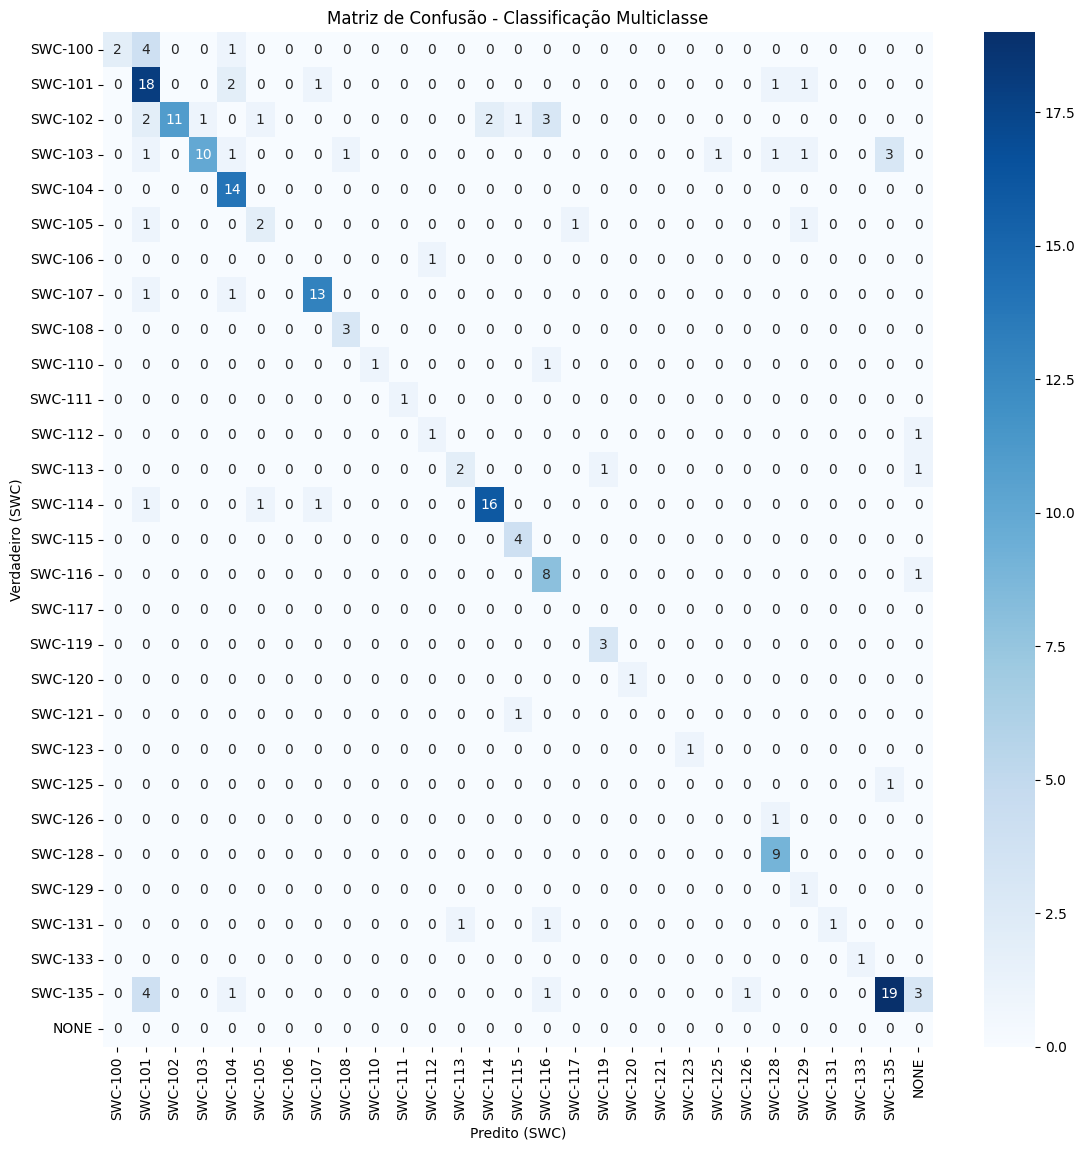

In [34]:
from difflib import get_close_matches

def extract_taxonomy_codes(taxonomia: str):
    """
    Extrai todos os códigos SWC (ex: SWC-101) da taxonomia.
    """
    lst = [x.strip() for x in taxonomia.split('\n') if x.strip()]
    codes = []
    for x in lst:
        m = re.search(r'SWC-\d+', x)
        if m:
            codes.append(m.group(0))
    return codes


def find_full_swc_label(label, taxonomy_lines):
    """
    Retorna o rótulo completo no formato SWC-###-Descrição.
    Corrige casos em que o LLM retornou apenas a descrição textual (ex: 'Typographical Error').
    """
    if not isinstance(label, str):
        return label.strip() if isinstance(label, str) else label

    label_clean = label.strip()

    # 1️⃣ Se já contém SWC-###, retorna normalizado
    swc_match = re.search(r'SWC-\d+', label_clean)
    if swc_match:
        return swc_match.group(0)

    # 2️⃣ Caso contrário, tenta achar uma linha da taxonomia que contenha a descrição
    match = get_close_matches(label_clean.lower(), [t.lower() for t in taxonomy_lines], n=1, cutoff=0.6)
    if match:
        # Recupera a linha original (com SWC completo)
        for line in taxonomy_lines:
            if match[0] in line.lower():
                full_match = re.search(r'SWC-\d+', line)
                if full_match:
                    return full_match.group(0)
                return line.strip()
    
    # 3️⃣ Se nada encontrado, retorna o rótulo original
    return label_clean


def normalize_to_swc(series, taxonomy_text):
    """
    Normaliza uma série de rótulos (strings ou números) para o formato SWC-###.
    """
    taxonomy_lines = [x.strip() for x in taxonomy_text.split('\n') if x.strip()]
    s = pd.Series(series).copy()

    if pd.api.types.is_integer_dtype(s) or pd.api.types.is_float_dtype(s):
        taxonomy_codes = extract_taxonomy_codes(taxonomy_text)
        s = s.astype(int).map(lambda i: taxonomy_codes[i] if 0 <= i < len(taxonomy_codes) else f"UNK-{i}")
    else:
        s = s.astype(str).map(lambda v: find_full_swc_label(v, taxonomy_lines))
    return s


def calculate_detailed_metrics(y_true, y_pred):
    metrics = {}
    for average in ['micro', 'macro', 'weighted']:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=average, zero_division=0
        )
        metrics[average] = {'precision': precision, 'recall': recall, 'f1': f1}

    print("=== Métricas Detalhadas ===")
    for avg_type in metrics:
        print(f"\nMétricas ({avg_type}):")
        print(f"Precisão: {metrics[avg_type]['precision']:.3f}")
        print(f"Recall: {metrics[avg_type]['recall']:.3f}")
        print(f"F1-Score: {metrics[avg_type]['f1']:.3f}")

    return metrics


# ---- Execução Principal ----
taxonomia_codes = extract_taxonomy_codes(taxonomia)

if not multiclass_results_df.empty:
    y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
    y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

    present_labels = sorted(pd.unique(pd.concat([y_true_codes, y_pred_codes])), key=lambda x: (x.startswith('SWC-'), x))
    labels_plot = [c for c in taxonomia_codes if c in set(present_labels)]
    fallback = [c for c in present_labels if c not in set(labels_plot)]
    labels_plot = labels_plot + fallback

    print("\nResultados da Classificação Multiclasse:")
    _metrics = calculate_detailed_metrics(y_true_codes, y_pred_codes)

    conf_mat = confusion_matrix(y_true_codes, y_pred_codes, labels=labels_plot)

    plt.figure(figsize=(max(8, 0.4*len(labels_plot)), max(6, 0.4*len(labels_plot))))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_plot, yticklabels=labels_plot)
    plt.title('Matriz de Confusão - Classificação Multiclasse')
    plt.ylabel('Verdadeiro (SWC)')
    plt.xlabel('Predito (SWC)')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum caso para análise multiclasse.")


In [ ]:
multiclass_results_df['true_label'].value_counts()


true_label
SWC-135-Code With No Effects                                       29
SWC-101-Integer Overflow and Underflow                             23
SWC-102-Outdated Compiler Version                                  21
SWC-114-Transaction Order Dependence                               19
SWC-103-Floating Pragma                                            19
SWC-107-Reentrancy                                                 15
SWC-104-Unchecked Call Return Value                                14
SWC-116-Block values as a proxy for time                            9
SWC-128-DoS With Block Gas Limit                                    9
SWC-100-Function Default Visibility                                 7
SWC-105-Unprotected Ether Withdrawal                                5
SWC-113-DoS with Failed Call                                        4
SWC-115-Authorization through tx.origin                             4
SWC-131-Presence of unused variables                                3
SWC-119-S

In [38]:
# --- Normalização usando a função que deu certo ---
y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

# Substitui as colunas antigas (para facilitar o uso posterior)
multiclass_results_df['true_label_swc'] = y_true_codes
multiclass_results_df['llm_label_swc'] = y_pred_codes

# --- 1️⃣ Contagem de labels preditas ---
print("=== Distribuição das classes preditas (normalizadas) ===\n")
display(multiclass_results_df['llm_label_swc'].value_counts().sort_index())



=== Distribuição das classes preditas (normalizadas) ===



llm_label_swc
NONE        6
SWC-100     2
SWC-101    32
SWC-102    11
SWC-103    11
SWC-104    20
SWC-105     4
SWC-107    15
SWC-108     4
SWC-110     1
SWC-111     1
SWC-112     2
SWC-113     3
SWC-114    18
SWC-115     6
SWC-116    14
SWC-117     1
SWC-119     4
SWC-120     1
SWC-123     1
SWC-125     1
SWC-126     1
SWC-128    12
SWC-129     4
SWC-131     1
SWC-133     1
SWC-135    23
Name: count, dtype: int64

#### Zero-shot CoT Prompting

In [ ]:
results_df = classify_dataset_gemini(subset, prompts.create_zeroshot_cot_locate_prompt, MODEL_NAME)
precision, recall, f1, conf_matrix = evaluate_experiment(results_df)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Confusion Matrix:\n{conf_matrix}")
results_df.head()

##### Classificação de erros pela LLM usando taxonomia

Nesta seção, vamos passar a taxonomia de erros para a LLM e pedir para ela classificar os casos de erro, comparando com as labels do dataset.

In [39]:
# Extração da taxonomia de categorias SWC (baseado em distribuicao.py)
category_list = []
real_base = '../../../Datasets/DAppSCAN-main/DAppSCAN-source/'
for item in bug_locations:
    relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
    location = os.path.join(real_base, relative_location)
    try:
        with open(location, 'r', encoding='utf-8') as f_swcs:
            swc_json = json.load(f_swcs)
            if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                for swc in swc_json['SWCs']:
                    if 'category' in swc:
                        category_list.append(swc['category'])
    except Exception as e:
        print(f"Could not read {location}: {e}")
taxonomia_raw = sorted(set(category_list))
# Formata a taxonomia como lista numerada para o prompt
taxonomia = '\n'.join([f"{i+1}. {cat}" for i, cat in enumerate(taxonomia_raw)])
#print("Taxonomia extraída e formatada:\n", taxonomia)

##### Classificação multiclasse usando taxonomia

In [ ]:
csv_path = "../../../Datasets/error_classification_task.csv"
df = pd.read_csv(csv_path)
df['has_error'] = df['has_error'].astype(bool)
subset_bug = df.reset_index(drop=True)

In [41]:
def get_true_category(file_path, bug_locations, real_base):
    """Obtém a categoria real do erro do arquivo SWC"""
    for item in bug_locations:
        if normalize_path(item['file']) in file_path:
            relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
            location = os.path.join(real_base, relative_location)
            try:
                with open(location, 'r', encoding='utf-8') as f_swcs:
                    swc_json = json.load(f_swcs)
                    if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                        # Retorna a primeira categoria encontrada
                        for swc in swc_json['SWCs']:
                            if 'category' in swc:
                                return swc['category']
            except Exception as e:
                print(f"Erro ao ler categoria: {e}")
    return "Categoria não encontrada"

In [49]:
def classify_multiclass(dataset, taxonomia, MODEL_NAME):
    results = []
    for idx, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Classificando arquivos", ncols=90):
        file_name = row.get('file_name', '')
        file_path = row.get('file_path', '')
        full_path = f'../../../Datasets/{file_path}'
        
        true_category = get_true_category(file_path, bug_locations, real_base)
        prompt = prompts.create_multiclass_prompt_cot(full_path, file_name, taxonomia)
        
        try:
            llm_response = call_gemini(MODEL_NAME, prompt)
            
            bug_type = "Não identificado"
            if isinstance(llm_response, str):
                # Tenta encontrar o campo bug_type mesmo que o JSON não seja perfeitamente formatado
                try:
                    response_json = json.loads(llm_response)
                    bug_type = response_json.get("bug_type", "").strip() or "Não identificado"
                except json.JSONDecodeError:
                    # Se não for JSON, tenta extrair via regex
                    import re
                    match = re.search(r'"bug_type"\s*:\s*"?([^"\n}]+)"?', llm_response)
                    if match:
                        bug_type = match.group(1).strip()
                    else:
                        bug_type = llm_response.strip()
            elif isinstance(llm_response, dict):
                bug_type = llm_response.get("bug_type", "Não identificado")
            else:
                bug_type = str(llm_response).strip()
            
            results.append({
                'id': idx,
                'file_path': file_path,
                'file_name': file_name,
                'true_label': true_category,
                'llm_label': bug_type
            })
        
        except Exception as e:
            tqdm.write(f"[Erro no processo {idx}] {e}")
    
    print("\nClassificação concluída.")
    return pd.DataFrame(results)


In [50]:
multiclass_results_df = classify_multiclass(subset_bug, taxonomia, MODEL_NAME)
multiclass_results_df.head()

Classificando arquivos: 100%|███████████████████████████| 200/200 [06:08<00:00,  1.84s/it]


Classificação concluída.


,id,file_path,file_name,true_label,llm_label
0,0,DAppSCAN-main/DAppSCAN-source/contracts/QuillA...,ERC20Permit.sol,SWC-114-Transaction Order Dependence,SWC-114-Transaction Order Dependence
1,1,DAppSCAN-main/DAppSCAN-source/contracts/Chains...,AccessControl.sol,SWC-103-Floating Pragma,SWC-103-Floating Pragma
2,2,DAppSCAN-main/DAppSCAN-source/contracts/Chains...,AccessControl.sol,SWC-103-Floating Pragma,SWC-103-Floating Pragma
3,3,DAppSCAN-main/DAppSCAN-source/contracts/openze...,HackerGold.sol,SWC-101-Integer Overflow and Underflow,SWC-101-Integer Overflow and Underflow
4,4,DAppSCAN-main/DAppSCAN-source/contracts/PeckSh...,UserConfiguration.sol,SWC-101-Integer Overflow and Underflow,SWC-101-Integer Overflow and Underflow



Resultados da Classificação Multiclasse:
=== Métricas Detalhadas ===

Métricas (micro):
Precisão: 0.690
Recall: 0.690
F1-Score: 0.690

Métricas (macro):
Precisão: 0.589
Recall: 0.577
F1-Score: 0.551

Métricas (weighted):
Precisão: 0.794
Recall: 0.690
F1-Score: 0.711


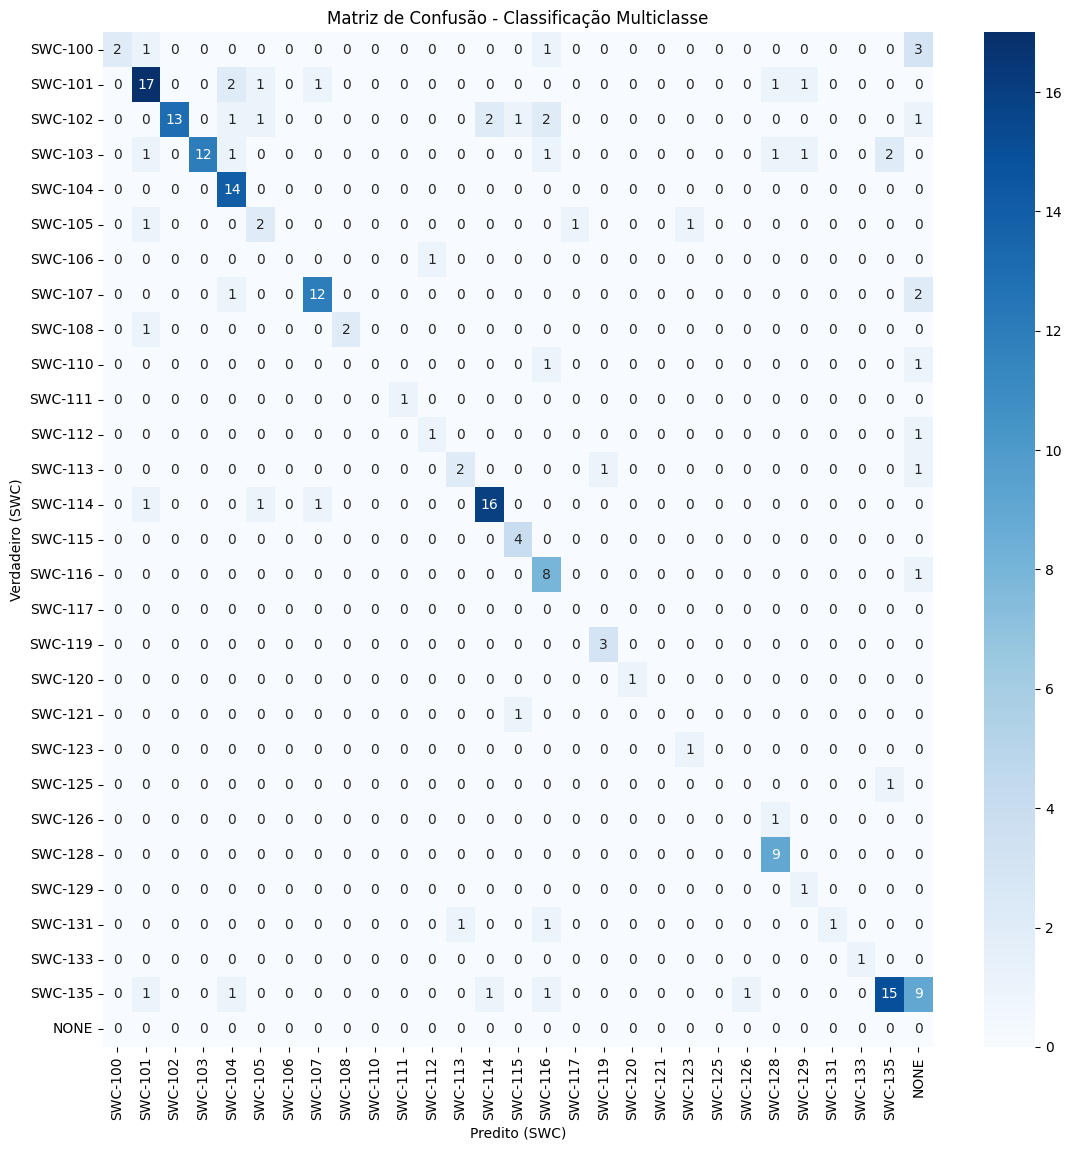

In [52]:
from difflib import get_close_matches

def extract_taxonomy_codes(taxonomia: str):
    """
    Extrai todos os códigos SWC (ex: SWC-101) da taxonomia.
    """
    lst = [x.strip() for x in taxonomia.split('\n') if x.strip()]
    codes = []
    for x in lst:
        m = re.search(r'SWC-\d+', x)
        if m:
            codes.append(m.group(0))
    return codes


def find_full_swc_label(label, taxonomy_lines):
    """
    Retorna o rótulo completo no formato SWC-###-Descrição.
    Corrige casos em que o LLM retornou apenas a descrição textual (ex: 'Typographical Error').
    """
    if not isinstance(label, str):
        return label.strip() if isinstance(label, str) else label

    label_clean = label.strip()

    # 1️⃣ Se já contém SWC-###, retorna normalizado
    swc_match = re.search(r'SWC-\d+', label_clean)
    if swc_match:
        return swc_match.group(0)

    # 2️⃣ Caso contrário, tenta achar uma linha da taxonomia que contenha a descrição
    match = get_close_matches(label_clean.lower(), [t.lower() for t in taxonomy_lines], n=1, cutoff=0.6)
    if match:
        # Recupera a linha original (com SWC completo)
        for line in taxonomy_lines:
            if match[0] in line.lower():
                full_match = re.search(r'SWC-\d+', line)
                if full_match:
                    return full_match.group(0)
                return line.strip()
    
    # 3️⃣ Se nada encontrado, retorna o rótulo original
    return label_clean


def normalize_to_swc(series, taxonomy_text):
    """
    Normaliza uma série de rótulos (strings ou números) para o formato SWC-###.
    """
    taxonomy_lines = [x.strip() for x in taxonomy_text.split('\n') if x.strip()]
    s = pd.Series(series).copy()

    if pd.api.types.is_integer_dtype(s) or pd.api.types.is_float_dtype(s):
        taxonomy_codes = extract_taxonomy_codes(taxonomy_text)
        s = s.astype(int).map(lambda i: taxonomy_codes[i] if 0 <= i < len(taxonomy_codes) else f"UNK-{i}")
    else:
        s = s.astype(str).map(lambda v: find_full_swc_label(v, taxonomy_lines))
    return s


def calculate_detailed_metrics(y_true, y_pred):
    metrics = {}
    for average in ['micro', 'macro', 'weighted']:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=average, zero_division=0
        )
        metrics[average] = {'precision': precision, 'recall': recall, 'f1': f1}

    print("=== Métricas Detalhadas ===")
    for avg_type in metrics:
        print(f"\nMétricas ({avg_type}):")
        print(f"Precisão: {metrics[avg_type]['precision']:.3f}")
        print(f"Recall: {metrics[avg_type]['recall']:.3f}")
        print(f"F1-Score: {metrics[avg_type]['f1']:.3f}")

    return metrics


# ---- Execução Principal ----
taxonomia_codes = extract_taxonomy_codes(taxonomia)

if not multiclass_results_df.empty:
    y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
    y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

    present_labels = sorted(pd.unique(pd.concat([y_true_codes, y_pred_codes])), key=lambda x: (x.startswith('SWC-'), x))
    labels_plot = [c for c in taxonomia_codes if c in set(present_labels)]
    fallback = [c for c in present_labels if c not in set(labels_plot)]
    labels_plot = labels_plot + fallback

    print("\nResultados da Classificação Multiclasse:")
    _metrics = calculate_detailed_metrics(y_true_codes, y_pred_codes)

    conf_mat = confusion_matrix(y_true_codes, y_pred_codes, labels=labels_plot)

    plt.figure(figsize=(max(8, 0.4*len(labels_plot)), max(6, 0.4*len(labels_plot))))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_plot, yticklabels=labels_plot)
    plt.title('Matriz de Confusão - Classificação Multiclasse')
    plt.ylabel('Verdadeiro (SWC)')
    plt.xlabel('Predito (SWC)')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum caso para análise multiclasse.")


In [ ]:
multiclass_results_df['true_label'].value_counts()

true_label
SWC-135-Code With No Effects                                       29
SWC-101-Integer Overflow and Underflow                             23
SWC-102-Outdated Compiler Version                                  21
SWC-114-Transaction Order Dependence                               19
SWC-103-Floating Pragma                                            19
SWC-107-Reentrancy                                                 15
SWC-104-Unchecked Call Return Value                                14
SWC-116-Block values as a proxy for time                            9
SWC-128-DoS With Block Gas Limit                                    9
SWC-100-Function Default Visibility                                 7
SWC-105-Unprotected Ether Withdrawal                                5
SWC-113-DoS with Failed Call                                        4
SWC-115-Authorization through tx.origin                             4
SWC-131-Presence of unused variables                                3
SWC-119-S

In [54]:
# --- Normalização usando a função que deu certo ---
y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

# Substitui as colunas antigas (para facilitar o uso posterior)
multiclass_results_df['true_label_swc'] = y_true_codes
multiclass_results_df['llm_label_swc'] = y_pred_codes

# --- 1️⃣ Contagem de labels preditas ---
print("=== Distribuição das classes preditas (normalizadas) ===\n")
display(multiclass_results_df['llm_label_swc'].value_counts().sort_index())



=== Distribuição das classes preditas (normalizadas) ===



llm_label_swc
NONE       19
SWC-100     2
SWC-101    23
SWC-102    13
SWC-103    12
SWC-104    20
SWC-105     5
SWC-107    14
SWC-108     2
SWC-111     1
SWC-112     2
SWC-113     3
SWC-114    19
SWC-115     6
SWC-116    15
SWC-117     1
SWC-119     4
SWC-120     1
SWC-123     2
SWC-126     1
SWC-128    12
SWC-129     3
SWC-131     1
SWC-133     1
SWC-135    18
Name: count, dtype: int64

#### Zero-shot ToT Prompting

In [ ]:
results_df = classify_dataset_gemini(subset, prompts.create_zeroshot_tot_locate_prompt, MODEL_NAME)
precision, recall, f1, conf_matrix = evaluate_experiment(results_df)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Confusion Matrix:\n{conf_matrix}")
results_df.head()

##### Classificação de erros pela LLM usando taxonomia

Nesta seção, vamos passar a taxonomia de erros para a LLM e pedir para ela classificar os casos de erro, comparando com as labels do dataset.

In [77]:
# Extração da taxonomia de categorias SWC (baseado em distribuicao.py)
category_list = []
real_base = '../../../Datasets/DAppSCAN-main/DAppSCAN-source/'
for item in bug_locations:
    relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
    location = os.path.join(real_base, relative_location)
    try:
        with open(location, 'r', encoding='utf-8') as f_swcs:
            swc_json = json.load(f_swcs)
            if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                for swc in swc_json['SWCs']:
                    if 'category' in swc:
                        category_list.append(swc['category'])
    except Exception as e:
        print(f"Could not read {location}: {e}")
taxonomia_raw = sorted(set(category_list))
# Formata a taxonomia como lista numerada para o prompt
taxonomia = '\n'.join([f"{i+1}. {cat}" for i, cat in enumerate(taxonomia_raw)])

##### Classificação multiclasse usando taxonomia

In [ ]:
csv_path = "../../../Datasets/error_classification_task.csv"
df = pd.read_csv(csv_path)
df['has_error'] = df['has_error'].astype(bool)
subset_bug = df.reset_index(drop=True)

In [79]:
def get_true_category(file_path, bug_locations, real_base):
    """Obtém a categoria real do erro do arquivo SWC"""
    for item in bug_locations:
        if normalize_path(item['file']) in file_path:
            relative_location = item['location'].replace("\\", os.sep).replace("/", os.sep)
            location = os.path.join(real_base, relative_location)
            try:
                with open(location, 'r', encoding='utf-8') as f_swcs:
                    swc_json = json.load(f_swcs)
                    if 'SWCs' in swc_json and isinstance(swc_json['SWCs'], list):
                        # Retorna a primeira categoria encontrada
                        for swc in swc_json['SWCs']:
                            if 'category' in swc:
                                return swc['category']
            except Exception as e:
                print(f"Erro ao ler categoria: {e}")
    return "Categoria não encontrada"

In [80]:
def classify_multiclass(dataset, taxonomia, MODEL_NAME):
    results = []
    for idx, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Classificando arquivos", ncols=90):
        file_name = row.get('file_name', '')
        file_path = row.get('file_path', '')
        full_path = f'../../../Datasets/{file_path}'
        
        true_category = get_true_category(file_path, bug_locations, real_base)
        prompt = prompts.create_multiclass_prompt_tot(full_path, file_name, taxonomia)
        
        try:
            llm_response = call_gemini(MODEL_NAME, prompt)
            
            bug_type = "Não identificado"
            if isinstance(llm_response, str):
                # Tenta encontrar o campo bug_type mesmo que o JSON não seja perfeitamente formatado
                try:
                    response_json = json.loads(llm_response)
                    bug_type = response_json.get("bug_type", "").strip() or "Não identificado"
                except json.JSONDecodeError:
                    # Se não for JSON, tenta extrair via regex
                    import re
                    match = re.search(r'"bug_type"\s*:\s*"?([^"\n}]+)"?', llm_response)
                    if match:
                        bug_type = match.group(1).strip()
                    else:
                        bug_type = llm_response.strip()
            elif isinstance(llm_response, dict):
                bug_type = llm_response.get("bug_type", "Não identificado")
            else:
                bug_type = str(llm_response).strip()
            
            results.append({
                'id': idx,
                'file_path': file_path,
                'file_name': file_name,
                'true_label': true_category,
                'llm_label': bug_type
            })
        
        except Exception as e:
            tqdm.write(f"[Erro no processo {idx}] {e}")
    
    print("\nClassificação concluída.")
    return pd.DataFrame(results)


In [81]:
multiclass_results_df = classify_multiclass(subset_bug, taxonomia, MODEL_NAME)
multiclass_results_df.head()

Classificando arquivos:  14%|███▉                        | 28/200 [02:19<10:00,  3.49s/it]

Attempt 1 failed: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.


Classificando arquivos:  28%|███████▊                    | 56/200 [03:26<05:37,  2.35s/it]

Attempt 1 failed: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.


Classificando arquivos:  32%|████████▉                   | 64/200 [04:00<08:21,  3.69s/it]

...

Classificando arquivos:  97%|██████████████████████████▏| 194/200 [21:04<00:34,  5.69s/it]

Attempt 1 failed: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.


Classificando arquivos: 100%|███████████████████████████| 200/200 [21:42<00:00,  6.51s/it]


Classificação concluída.


,id,file_path,file_name,true_label,llm_label
0,0,DAppSCAN-main/DAppSCAN-source/contracts/QuillA...,ERC20Permit.sol,SWC-114-Transaction Order Dependence,SWC-114-Transaction Order Dependence
1,1,DAppSCAN-main/DAppSCAN-source/contracts/Chains...,AccessControl.sol,SWC-103-Floating Pragma,SWC-103-Floating Pragma
2,2,DAppSCAN-main/DAppSCAN-source/contracts/Chains...,AccessControl.sol,SWC-103-Floating Pragma,SWC-103-Floating Pragma
3,3,DAppSCAN-main/DAppSCAN-source/contracts/openze...,HackerGold.sol,SWC-101-Integer Overflow and Underflow,SWC-131-Presence of unused variables
4,4,DAppSCAN-main/DAppSCAN-source/contracts/PeckSh...,UserConfiguration.sol,SWC-101-Integer Overflow and Underflow,SWC-101-Integer Overflow and Underflow



Resultados da Classificação Multiclasse:
=== Métricas Detalhadas ===

Métricas (micro):
Precisão: 0.590
Recall: 0.590
F1-Score: 0.590

Métricas (macro):
Precisão: 0.533
Recall: 0.518
F1-Score: 0.505

Métricas (weighted):
Precisão: 0.747
Recall: 0.590
F1-Score: 0.641


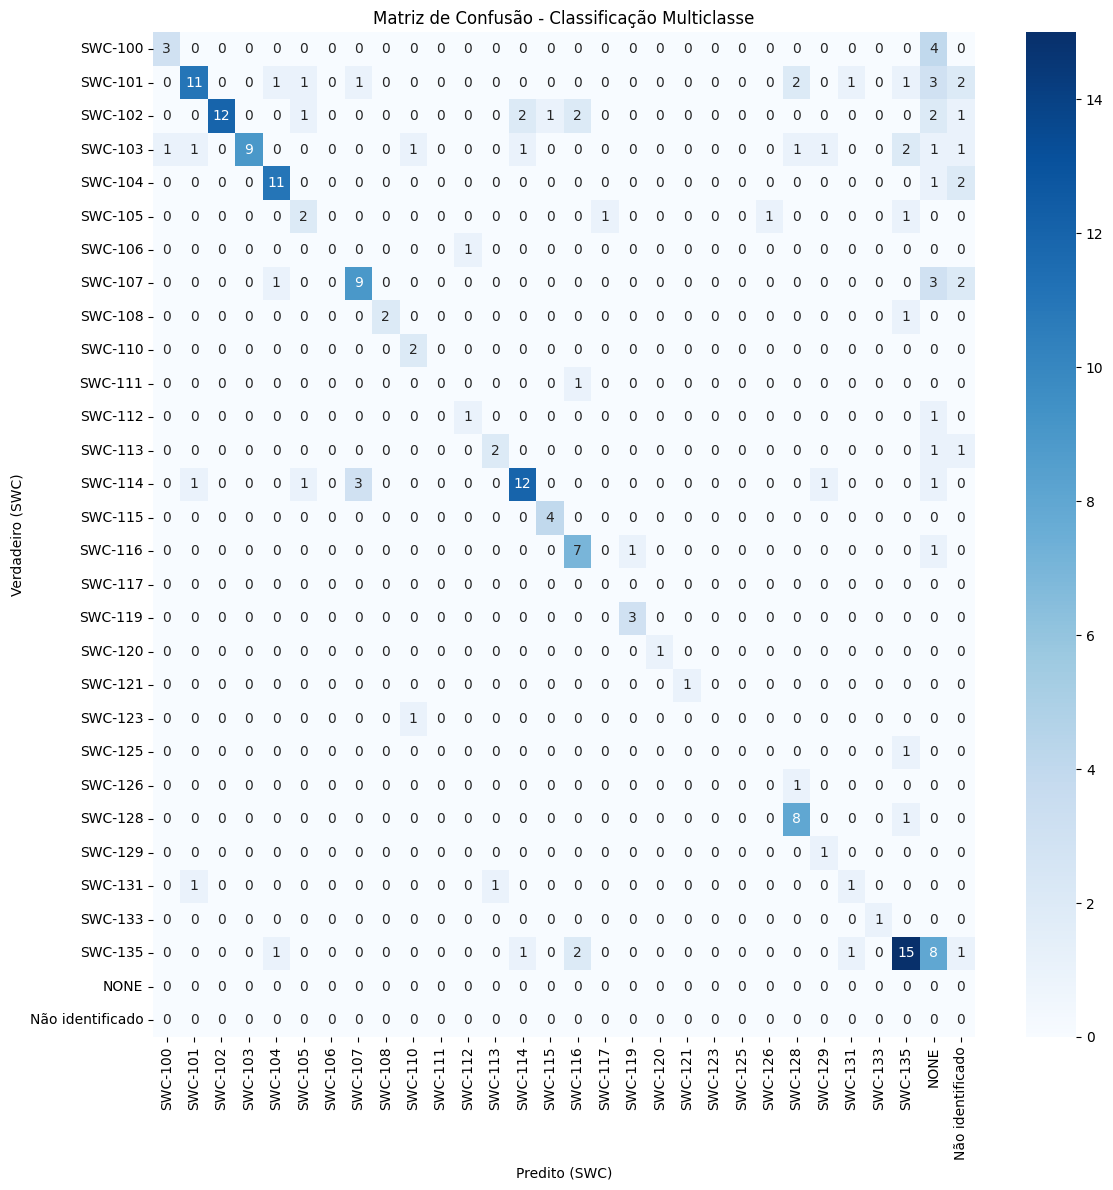

In [85]:
from difflib import get_close_matches

def extract_taxonomy_codes(taxonomia: str):
    """
    Extrai todos os códigos SWC (ex: SWC-101) da taxonomia.
    """
    lst = [x.strip() for x in taxonomia.split('\n') if x.strip()]
    codes = []
    for x in lst:
        m = re.search(r'SWC-\d+', x)
        if m:
            codes.append(m.group(0))
    return codes


def find_full_swc_label(label, taxonomy_lines):
    """
    Retorna o rótulo completo no formato SWC-###-Descrição.
    Corrige casos em que o LLM retornou apenas a descrição textual (ex: 'Typographical Error').
    """
    if not isinstance(label, str):
        return label.strip() if isinstance(label, str) else label

    label_clean = label.strip()

    # 1️⃣ Se já contém SWC-###, retorna normalizado
    swc_match = re.search(r'SWC-\d+', label_clean)
    if swc_match:
        return swc_match.group(0)

    # 2️⃣ Caso contrário, tenta achar uma linha da taxonomia que contenha a descrição
    match = get_close_matches(label_clean.lower(), [t.lower() for t in taxonomy_lines], n=1, cutoff=0.6)
    if match:
        # Recupera a linha original (com SWC completo)
        for line in taxonomy_lines:
            if match[0] in line.lower():
                full_match = re.search(r'SWC-\d+', line)
                if full_match:
                    return full_match.group(0)
                return line.strip()
    
    # 3️⃣ Se nada encontrado, retorna o rótulo original
    return label_clean


def normalize_to_swc(series, taxonomy_text):
    """
    Normaliza uma série de rótulos (strings ou números) para o formato SWC-###.
    """
    taxonomy_lines = [x.strip() for x in taxonomy_text.split('\n') if x.strip()]
    s = pd.Series(series).copy()

    if pd.api.types.is_integer_dtype(s) or pd.api.types.is_float_dtype(s):
        taxonomy_codes = extract_taxonomy_codes(taxonomy_text)
        s = s.astype(int).map(lambda i: taxonomy_codes[i] if 0 <= i < len(taxonomy_codes) else f"UNK-{i}")
    else:
        s = s.astype(str).map(lambda v: find_full_swc_label(v, taxonomy_lines))
    return s


def calculate_detailed_metrics(y_true, y_pred):
    metrics = {}
    for average in ['micro', 'macro', 'weighted']:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=average, zero_division=0
        )
        metrics[average] = {'precision': precision, 'recall': recall, 'f1': f1}

    print("=== Métricas Detalhadas ===")
    for avg_type in metrics:
        print(f"\nMétricas ({avg_type}):")
        print(f"Precisão: {metrics[avg_type]['precision']:.3f}")
        print(f"Recall: {metrics[avg_type]['recall']:.3f}")
        print(f"F1-Score: {metrics[avg_type]['f1']:.3f}")

    return metrics


# ---- Execução Principal ----
taxonomia_codes = extract_taxonomy_codes(taxonomia)

if not multiclass_results_df.empty:
    y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
    y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

    present_labels = sorted(pd.unique(pd.concat([y_true_codes, y_pred_codes])), key=lambda x: (x.startswith('SWC-'), x))
    labels_plot = [c for c in taxonomia_codes if c in set(present_labels)]
    fallback = [c for c in present_labels if c not in set(labels_plot)]
    labels_plot = labels_plot + fallback

    print("\nResultados da Classificação Multiclasse:")
    _metrics = calculate_detailed_metrics(y_true_codes, y_pred_codes)

    conf_mat = confusion_matrix(y_true_codes, y_pred_codes, labels=labels_plot)

    plt.figure(figsize=(max(8, 0.4*len(labels_plot)), max(6, 0.4*len(labels_plot))))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_plot, yticklabels=labels_plot)
    plt.title('Matriz de Confusão - Classificação Multiclasse')
    plt.ylabel('Verdadeiro (SWC)')
    plt.xlabel('Predito (SWC)')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum caso para análise multiclasse.")


In [86]:
multiclass_results_df['true_label'].value_counts()


true_label
SWC-135-Code With No Effects                                       29
SWC-101-Integer Overflow and Underflow                             23
SWC-102-Outdated Compiler Version                                  21
SWC-114-Transaction Order Dependence                               19
SWC-103-Floating Pragma                                            19
SWC-107-Reentrancy                                                 15
SWC-104-Unchecked Call Return Value                                14
SWC-116-Block values as a proxy for time                            9
SWC-128-DoS With Block Gas Limit                                    9
SWC-100-Function Default Visibility                                 7
SWC-105-Unprotected Ether Withdrawal                                5
SWC-113-DoS with Failed Call                                        4
SWC-115-Authorization through tx.origin                             4
SWC-131-Presence of unused variables                                3
SWC-119-S

In [88]:
# --- Normalização usando a função que deu certo ---
y_true_codes = normalize_to_swc(multiclass_results_df['true_label'], taxonomia)
y_pred_codes = normalize_to_swc(multiclass_results_df['llm_label'], taxonomia)

# Substitui as colunas antigas (para facilitar o uso posterior)
multiclass_results_df['true_label_swc'] = y_true_codes
multiclass_results_df['llm_label_swc'] = y_pred_codes

# --- 1️⃣ Contagem de labels preditas ---
print("=== Distribuição das classes preditas (normalizadas) ===\n")
display(multiclass_results_df['llm_label_swc'].value_counts().sort_index())



=== Distribuição das classes preditas (normalizadas) ===



llm_label_swc
NONE                26
Não identificado    10
SWC-100              4
SWC-101             14
SWC-102             12
SWC-103              9
SWC-104             14
SWC-105              5
SWC-107             13
SWC-108              2
SWC-110              4
SWC-112              2
SWC-113              3
SWC-114             16
SWC-115              5
SWC-116             12
SWC-117              1
SWC-119              4
SWC-120              1
SWC-121              1
SWC-126              1
SWC-128             12
SWC-129              3
SWC-131              3
SWC-133              1
SWC-135             22
Name: count, dtype: int64